<a href="https://colab.research.google.com/github/Sriharikrishnan-TS/Portfolio_Projects/blob/main/resnet_18_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**VEHICLE IMAGE CLASSIFICATION**



1) importing all necessary libraries

In [ ]:
import torch
from torchvision import datasets
import torchvision.transforms as transforms
import torchvision.models as models
import torch.optim as optim
import torch.nn as nn
import os
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader,random_split
import numpy as np

2) Mount Google Drive to access the vehicle dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


3) create the datset path

we will be splitting the dataset into test and train later

In [ ]:
train_dir = "/content/drive/MyDrive/vehicles_split/train"
test_dir = "/content/drive/MyDrive/vehicles_split/test"
class_names = sorted(os.listdir(train_dir))

4) Preprocessing step

i) **transforms.Compose()** - combines multiple tranformations together in sequential order

ii) **transforms.Resize**((244,244)) - ResNet18 model expects the input size usually to be 244 x 244 pixels

iii) **transforms.ToTensor**() - converts the image to pytorch Tensor which is represented in **(C,H,W)** format

C is the number of channels (3 for RGB).

H is the height.

W is the width.

iv) **transforms.Normalize()** - normalizes pixels for better training,
to ensure uniform pixel distribution

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Lambda(lambda image: image.convert("RGBA")),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

**SPLIT THE DATASET FOR TEST AND TRAINING**

usually we follow 80-20 rule

(80% of data for training and 20% for testing,cross-validation)

In [ ]:
import random
from pathlib import Path
import shutil
source_dir = "/content/drive/MyDrive/Vehicles"  # Replace with your path
train_dir = "/content/drive/MyDrive/vehicles_split/train"
test_dir = "/content/drive/MyDrive/vehicles_split/test"

split_ratio = 0.8  # 80% train, 20% test

# Create destination directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Loop through each class folder
for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    # Create class subfolders in train and test
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

    # List all images and shuffle
    images=[]
    for f in os.listdir(class_path):
      if f.lower().endswith((".jpg", ".png", ".jpeg")):
        images.append(f)
    random.shuffle(images)
    # images = [f for f in os.listdir(class_path) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
    # random.shuffle(images)

    # Split into train and test
    split_idx = int(len(images) * split_ratio)
    train_images = images[:split_idx]
    test_images = images[split_idx:]

    # Copy files to destination
    for img in train_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(train_dir, class_name, img)
        #It copies the file from src to dst
        shutil.copy2(src, dst)

    for img in test_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(test_dir, class_name, img)
        shutil.copy2(src, dst)

print("Dataset successfully split into train and test sets.")

Dataset successfully split into train and test sets.


**CREATE DATA LOADERS**

DataLoaders are mainly created for splitting data into mini batches to work on

batch_size - size of the mini-batch

Each item in the train_dataloader is a tuple containing:

**Inputs:** A batch of images (usually a tensor of shape [batch_size, channels, height, width])

**Labels:** A batch of labels (a tensor of shape [batch_size] containing the correct class index for each image)

In [ ]:
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,num_workers=2,pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

**LOAD THE ResNet18 MODEL**

***model.resnet18(pretrained=True)*** - loads the resnet18 model and by setting pretrained to true it means it uses a version of model htat was already trained on ImageNet dataset(which helps in faster learning)

***model.fc.in_features*** - gets the no of input features to the final fully connected layer of resnet18(the final layer may vary with different tasks)

***nn.Linear(num_ftrs, 7)*** - as we saw in the above definition now we are replacing teh output layer of resnet with our desired layer**(as we have only 7 output classes)**

In [ ]:
#used to automatically select the best hardware (GPU if available, else CPU) for training your model in PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 7)  # 7 vehicle classes
model = model.to(device)#moving the model to our computing device

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 147MB/s]


LOSS AND OPTIMIZER



In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

**USING timeit MODULE TO CLACULATE THE TRAINING AND TESTING TIME**

In [ ]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Returns:
        time between start and end in seconds (higher is longer).
    """
    seconds = end - start
    minutes = seconds // 60
    remaining_seconds = seconds % 60
    print(f"Train time on {device}:")
    print(f"{int(minutes)} min {int(remaining_seconds)} sec")
    return seconds

**CREATE TRAINING LOOP**



In [ ]:
from tqdm.auto import tqdm
#to make our experiment reporducible
#to get the same result everytime we run the code
torch.manual_seed(42)
start_time = timer()
def train_model():
  #epochs - the no of passes through the model
  epochs = 12
  model.train()

  for epoch in tqdm(range(epochs)):
    running_loss = 0.0
    correct = 0
    total = 0


    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()#sets the gradient to zero for next iteration
        # outputs - raw prediction scores(logits)
        outputs = model(inputs)

        loss = loss_fn(outputs, labels)

        loss.backward()

        optimizer.step()


        #loss.item() gives the scalar value of loss for the batch

        #imput.size(0) gives the batch size

        #multiplying the both gives the overall loss

        running_loss += loss.item() * inputs.size(0)

        #torch.max(outputs, 1) returns two things:

        #The maximum value in each row (not needed here, so it's _).

        #The index of the max value - this is the predicted class for each sample.

        _, predicted = torch.max(outputs, 1)
        #to calculate the accuracy we need to know how many of the outputs
        #are correctly labeled

        #predicted == labels returns tensor with True/False values
        #.sum() counts the true values
        #.item() converts to scalar
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

def test_model():
  #evaluation mode
  model.eval()
  correct = 0
  total = 0
  with torch.inference_mode():
      for inputs, labels in test_loader:
          inputs, labels = inputs.to(device), labels.to(device)
          outputs = model(inputs)
          _, predicted = torch.max(outputs, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

  print(f'Test Accuracy: {100 * correct / total:.2f}%')

train_model()
test_model()

# Calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=start_time,
                                           end=train_time_end_on_cpu,
                                           device=str(next(model.parameters()).device))

  0%|          | 0/12 [00:00<?, ?it/s]

Epoch [1/12], Loss: 0.0344, Accuracy: 0.9886
Epoch [2/12], Loss: 0.0487, Accuracy: 0.9852
Epoch [3/12], Loss: 0.0196, Accuracy: 0.9940
Epoch [4/12], Loss: 0.0085, Accuracy: 0.9971
Epoch [5/12], Loss: 0.0022, Accuracy: 0.9996
Epoch [6/12], Loss: 0.0006, Accuracy: 1.0000
Epoch [7/12], Loss: 0.0003, Accuracy: 1.0000
Epoch [8/12], Loss: 0.0001, Accuracy: 1.0000
Epoch [9/12], Loss: 0.0002, Accuracy: 1.0000
Epoch [10/12], Loss: 0.0001, Accuracy: 1.0000
Epoch [11/12], Loss: 0.0002, Accuracy: 1.0000
Epoch [12/12], Loss: 0.0002, Accuracy: 1.0000
Test Accuracy: 94.81%
Train time on cuda:0:
10 min 5 sec


**Saving the model for later use**

In [ ]:
import torch

# Assuming 'model' is your trained model
# Define the path in your Google Drive where you want to save it
save_path = '/content/drive/MyDrive/my_models/vehicle_classifier_resnet18.pth' # Create 'my_models' folder in Drive if not exists

# Make sure the directory exists before saving
import os
os.makedirs(os.path.dirname(save_path), exist_ok=True)

torch.save(model.state_dict(), save_path)
print(f"Model saved to: {save_path}")

Model saved to: /content/drive/MyDrive/my_models/vehicle_classifier_resnet18.pth


**PRINTING IMAGE FROM EACH CLASS**


Prediction on one image from each class:



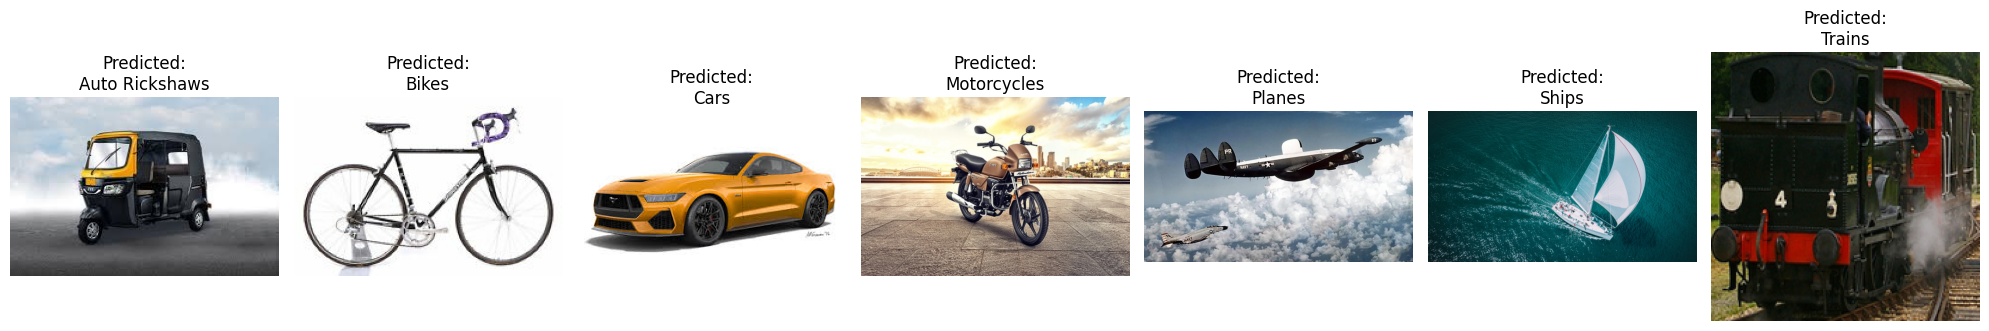

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

print("\nPrediction on one image from each class:\n")
model.eval()

plt.figure(figsize=(20, 5))  # wide figure for side-by-side display

for idx, class_name in enumerate(class_names):
    class_folder = os.path.join(test_dir, class_name)
    image_name = os.listdir(class_folder)[1]  # pick first image from class
    image_path = os.path.join(class_folder, image_name)

    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        _, pred = torch.max(output, 1)
        predicted_class = class_names[pred.item()]

    plt.subplot(1, len(class_names), idx + 1)  # 1 row, N cols
    plt.imshow(image)
    plt.title(f"Predicted:\n{predicted_class}")
    plt.axis('off')

plt.tight_layout()
plt.show()


**TO LOAD THE MODEL AGAIN**

In [ ]:
# Define the path to your saved model file
load_path = '/content/drive/MyDrive/my_models/vehicle_classifier_resnet18.pth' # Or '/content/vehicle_classifier_resnet18.pth' if you saved it temporarily

# Load the state_dict
# Use map_location to load it onto CPU if your GPU is not available, then move to device
model.load_state_dict(torch.load(load_path, map_location=device))

# Set the model to evaluation mode (important for inference)
model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def test_model():
  #evaluation mode
  model.eval()
  all_preds = []
  all_labels = []
  with torch.inference_mode():
      for inputs, labels in test_loader:
          inputs, labels = inputs.to(device), labels.to(device)
          outputs = model(inputs)
          _, predicted = torch.max(outputs, 1)
          all_preds.extend(predicted.cpu().numpy())
          all_labels.extend(labels.cpu().numpy())

          #now compute metrics
          accuracy = accuracy_score(all_labels, all_preds)
          precision = precision_score(all_labels, all_preds, average='weighted',zero_division=0)
          recall = recall_score(all_labels, all_preds, average='weighted',zero_division=0)
          f1 = f1_score(all_labels, all_preds, average='weighted',zero_division=0)

      print(f'Test Accuracy: {100 * accuracy:.2f}%')
      print(f'Test Precision: {100 * precision:.2f}%')
      print(f'Test Recall: {100 * recall:.2f}%')
      print(f'Test f1 score:{100 * f1:.2f}%')

test_model()

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Test Accuracy: 97.11%
Test Precision: 97.14%
Test Recall: 97.11%
Test f1 score:97.11%
